In [17]:
import re

with open('../data/transcript_raw/podcast/podcast_1.txt', 'r', encoding='utf-8') as f:
    # Only keep the lines that do NOT match the timestamp format (e.g., 0:06)
    content = [line for line in f if not re.match(r'^\d+:\d+', line)]

# Write the cleaned content to the destination file
with open('../data/transcript_processed/podcast/podcast_1.txt', 'w', encoding='utf-8') as f:
    f.writelines(content)

print("File processed and saved to ./transcript_processed/podcast/podcast_1.txt")

File processed and saved to ./transcripts_processed/podcasts/pc_1.txt


In [18]:
import pandas as pd
import os
import json

# 1. Cấu hình đường dẫn
input_folder = "../data/hsk_vocab_raw/"
output_folder = "../data/hsk_vocab_processed/"

# Tạo thư mục đầu ra nếu chưa tồn tại
os.makedirs(output_folder, exist_ok=True)

def process_meaning(text):
    """
    Tách chuỗi thành mảng các nghĩa.
    Xử lý cả trường hợp nhiều nghĩa trong 1 ô (ngắt dòng bằng Alt+Enter)
    """
    if pd.isna(text):
        return []
    # Thay thế các kiểu ngắt dòng khác nhau và tách thành list
    meanings = str(text).replace('\r', '\n').split('\n')
    # Loại bỏ khoảng trắng thừa và lọc bỏ các chuỗi rỗng
    return [m.strip() for m in meanings if m.strip()]

def clean_stt(value, default_index):
    """Ép STT về số nguyên sạch"""
    if pd.isna(value):
        return default_index
    try:
        return int(float(value))
    except (ValueError, TypeError):
        return str(value).strip()

# 2. Duyệt tất cả file trong thư mục đầu vào
for file_name in os.listdir(input_folder):
    # Chỉ xử lý file Excel và bỏ qua các file tạm của hệ thống
    if file_name.endswith(".xlsx") and not file_name.startswith((".", "~$")):
        file_path = os.path.join(input_folder, file_name)
        
        try:
            # Đọc file không dùng header (vì ta sẽ truy cập theo chỉ số cột 0, 1, 2...)
            df = pd.read_excel(file_path, header=None, engine='openpyxl')
            
            processed_dict = {}
            current_hanzi = None  # Biến lưu vết từ Hán đang xử lý cho các dòng gộp
            
            for index, row in df.iterrows():
                # Giả định cấu trúc cột: 0:STT, 1:Hanzi, 2:Pinyin, 3:Vietnamese, 4:English
                raw_hanzi = str(row[1]).strip() if pd.notna(row[1]) else ""
                
                # TRƯỜNG HỢP A: Có Hanzi mới -> Khởi tạo Object mới trong Dictionary
                if raw_hanzi:
                    current_hanzi = raw_hanzi
                    processed_dict[current_hanzi] = {
                        "id": clean_stt(row[0], index + 1),
                        "pinyin": str(row[2]).strip() if pd.notna(row[2]) else "",
                        "vietnamese": process_meaning(row[3]),
                        "english": process_meaning(row[4])
                    }
                
                # TRƯỜNG HỢP B: Hanzi trống nhưng có current_hanzi (Dòng phụ/Dòng gộp)
                elif current_hanzi is not None:
                    new_vi = process_meaning(row[3])
                    new_en = process_meaning(row[4])
                    
                    # Nối thêm nghĩa vào danh sách đã có thay vì ghi đè
                    if new_vi:
                        processed_dict[current_hanzi]["vietnamese"].extend(new_vi)
                    if new_en:
                        processed_dict[current_hanzi]["english"].extend(new_en)
            
            # 3. Hậu xử lý: Loại bỏ trùng lặp nghĩa (nếu có) trong từng từ
            for hanzi in processed_dict:
                processed_dict[hanzi]["vietnamese"] = list(dict.fromkeys(processed_dict[hanzi]["vietnamese"]))
                processed_dict[hanzi]["english"] = list(dict.fromkeys(processed_dict[hanzi]["english"]))

            # 4. Lưu file JSON
            output_file_name = file_name.replace(".xlsx", ".json")
            output_path = os.path.join(output_folder, output_file_name)
            
            with open(output_path, 'w', encoding='utf-8') as f:
                json.dump(processed_dict, f, ensure_ascii=False, indent=4)
                
            print(f"✅ Đã xử lý thành công: {file_name}")
            
        except Exception as e:
            print(f"❌ Lỗi khi xử lý file {file_name}: {e}")

print("\n--- HOÀN TẤT: Dữ liệu đã được gộp dòng và tối ưu O(1) ---")

✅ Đã xử lý thành công: hsk_5.xlsx
✅ Đã xử lý thành công: hsk_4.xlsx
✅ Đã xử lý thành công: hsk_3.xlsx
✅ Đã xử lý thành công: hsk_789_part_3.xlsx
✅ Đã xử lý thành công: hsk_789_part_2.xlsx
✅ Đã xử lý thành công: hsk_2.xlsx
✅ Đã xử lý thành công: hsk_789_part_1.xlsx
✅ Đã xử lý thành công: hsk_1.xlsx
✅ Đã xử lý thành công: hsk_6.xlsx

--- HOÀN TẤT: Dữ liệu đã được gộp dòng và tối ưu O(1) ---


In [ ]:
# import jieba
# import re
# import os
# import json
# from collections import Counter
# from pypinyin import pinyin, Style

# # --- CẤU HÌNH ---
# SORT_BY = "HSK_LEVEL" # Tùy chọn: "FREQ" hoặc "HSK_LEVEL"
# JSON_FOLDER = "../data/hsk_vocab_processed/"
# TRANSCRIPT_PATH = '../data/transcript_raw/podcast/podcast_1.txt'

# def get_hsk_num(hsk_string):
#     """Trích xuất số từ tên file (vd: 'hsk2' -> 2). Nếu không có HSK thì trả về 999"""
#     if hsk_string == "None":
#         return 999
#     nums = re.findall(r'\d+', hsk_string)
#     return int(nums[0]) if nums else 998

# def load_hsk_data(folder_path):
#     combined_hsk = {}
#     if not os.path.exists(folder_path):
#         return combined_hsk

#     for file_name in os.listdir(folder_path):
#         if file_name.endswith(".json"):
#             level_label = file_name.replace(".json", "")
#             try:
#                 with open(os.path.join(folder_path, file_name), 'r', encoding='utf-8') as f:
#                     data = json.load(f)
#                     for hanzi in data.keys():
#                         # Lưu cấp độ thấp nhất nếu từ xuất hiện ở nhiều file
#                         if hanzi not in combined_hsk:
#                             combined_hsk[hanzi] = level_label
#             except Exception:
#                 pass
#     return combined_hsk

# def extract_vocabulary(text, hsk_lookup):
#     text = re.sub(r'[^\u4e00-\u9fa5]', '', text) 
#     words = jieba.lcut(text)
#     vocab_counts = Counter(words)
    
#     # Tạo list thô: (word, count, hsk_label)
#     vocab_list = []
#     for word, count in vocab_counts.items():
#         vocab_list.append((word, count, hsk_lookup.get(word, "None")))

#     # --- LOGIC SẮP XẾP ---
#     if SORT_BY == "FREQ":
#         # Ưu tiên tần suất cao lên trước
#         vocab_list.sort(key=lambda x: x[1], reverse=True)
#     elif SORT_BY == "HSK_LEVEL":
#         # Ưu tiên HSK thấp lên trước (1 -> 2 -> 3...), sau đó mới đến tần suất
#         vocab_list.sort(key=lambda x: (get_hsk_num(x[2]), -x[1]))
    
#     return vocab_list

# def get_pinyin(word):
#     py_list = pinyin(word, style=Style.TONE)
#     return "".join([item[0] for item in py_list])

# # --- CHƯƠNG TRÌNH CHÍNH ---
# try:
#     hsk_lookup = load_hsk_data(JSON_FOLDER)

#     with open(TRANSCRIPT_PATH, 'r', encoding='utf-8') as f:
#         transcript = f.read() 

#     # Lấy danh sách đã được sắp xếp theo tùy chọn
#     vocabulary = extract_vocabulary(transcript, hsk_lookup)

#     print(f"Sorting by: {SORT_BY}")
#     print(f"{'No.':<5} | {'Word':<10} | {'Pinyin':<15} | {'Freq':<6} | {'HSK Level':<10}")
#     print("-" * 65)

#     for index, (word, count, hsk_level) in enumerate(vocabulary, start=1):
#         py = get_pinyin(word)
#         print(f"{index:<5} | {word:<10} | {py:<15} | {count:<6} | {hsk_level:<10}")

# except Exception as e:
#     print(f"Lỗi: {e}")

/opt/anaconda3/envs/learning_chinese_as_a_journey/lib/python3.9/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Dumping model to file cache /var/folders/b_/0jy0qw094lxg_fhjn1359cq00000gn/T/jieba.cache
Loading model cost 0.630 seconds.
Prefix dict has been built successfully.


Sorting by: HSK_LEVEL
No.   | Word       | Pinyin          | Freq   | HSK Level 
-----------------------------------------------------------------
1     | 的          | de              | 121    | hsk_1     
2     | 你          | nǐ              | 97     | hsk_1     
3     | 我          | wǒ              | 75     | hsk_1     
4     | 了          | le              | 64     | hsk_1     
5     | 是          | shì             | 43     | hsk_1     
6     | 不          | bù              | 34     | hsk_1     
7     | 说          | shuō            | 33     | hsk_1     
8     | 朋友         | péngyǒu         | 27     | hsk_1     
9     | 我们         | wǒmen           | 24     | hsk_1     
10    | 她          | tā              | 19     | hsk_1     
11    | 中国         | zhōngguó        | 18     | hsk_1     
12    | 吗          | ma              | 18     | hsk_1     
13    | 就          | jiù             | 18     | hsk_1     
14    | 知道         | zhīdào          | 16     | hsk_1     
15    | 在          | zài   

In [19]:
import jieba
import re
import os
import json
from collections import Counter
from pypinyin import pinyin, Style
from deep_translator import GoogleTranslator

# --- CẤU HÌNH ---
SORT_BY = "HSK_LEVEL"  # "FREQ" hoặc "HSK_LEVEL"
JSON_FOLDER = "../data/hsk_vocab_processed/"
TRANSCRIPT_PATH = '../data/transcript_raw/podcast/podcast_1.txt'
CACHE_FILE = "../cache/translation_cache.json"

# Khởi tạo bộ dịch
translator_vi = GoogleTranslator(source='zh-CN', target='vi')
translator_en = GoogleTranslator(source='zh-CN', target='en')

def load_cache():
    if os.path.exists(CACHE_FILE):
        try:
            with open(CACHE_FILE, 'r', encoding='utf-8') as f:
                return json.load(f)
        except: return {}
    return {}

def save_cache(cache_data):
    os.makedirs(os.path.dirname(CACHE_FILE), exist_ok=True)
    with open(CACHE_FILE, 'w', encoding='utf-8') as f:
        json.dump(cache_data, f, ensure_ascii=False, indent=4)

def get_hsk_num(hsk_string):
    if hsk_string == "None": return 999
    nums = re.findall(r'\d+', hsk_string)
    return int(nums[0]) if nums else 998

def load_hsk_data(folder_path):
    combined_hsk = {}
    if not os.path.exists(folder_path): return combined_hsk
    
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".json"):
            level_label = file_name.replace(".json", "")
            try:
                with open(os.path.join(folder_path, file_name), 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    for hanzi, info in data.items():
                        if hanzi not in combined_hsk:
                            # Nối nghĩa Tiếng Việt và Tiếng Anh bằng dấu ";"
                            vi_meanings = " ; ".join(info.get("vietnamese", []))
                            en_meanings = " ; ".join(info.get("english", []))
                            combined_hsk[hanzi] = {
                                "level": level_label, 
                                "vi": vi_meanings,
                                "en": en_meanings
                            }
            except: pass
    return combined_hsk

def extract_vocabulary(text, hsk_lookup):
    cache = load_cache()
    new_translations = False
    
    text = re.sub(r'[^\u4e00-\u9fa5]', '', text) 
    words = jieba.lcut(text)
    vocab_counts = Counter(words)
    
    vocab_list = []
    for word, count in vocab_counts.items():
        hsk_info = hsk_lookup.get(word)
        
        if hsk_info:
            level = hsk_info["level"]
            meaning_vi = hsk_info["vi"]
            meaning_en = hsk_info["en"]
        else:
            level = "None"
            # Kiểm tra trong cache (cache lưu dạng { "word": {"vi": "...", "en": "..."} })
            if word in cache and isinstance(cache[word], dict):
                meaning_vi = cache[word].get("vi", "N/A")
                meaning_en = cache[word].get("en", "N/A")
            else:
                try:
                    meaning_vi = translator_vi.translate(word)
                    meaning_en = translator_en.translate(word)
                    cache[word] = {"vi": meaning_vi, "en": meaning_en}
                    new_translations = True
                except:
                    meaning_vi = "N/A"
                    meaning_en = "N/A"
            
        vocab_list.append({
            "word": word, "count": count,
            "pinyin": "".join([item[0] for item in pinyin(word, style=Style.TONE)]),
            "level": level, "vi": meaning_vi, "en": meaning_en
        })

    if new_translations:
        save_cache(cache)

    if SORT_BY == "FREQ":
        vocab_list.sort(key=lambda x: x["count"], reverse=True)
    elif SORT_BY == "HSK_LEVEL":
        vocab_list.sort(key=lambda x: (get_hsk_num(x["level"]), -x["count"]))
    
    return vocab_list

# --- CHƯƠNG TRÌNH CHÍNH ---
try:
    hsk_lookup = load_hsk_data(JSON_FOLDER)
    with open(TRANSCRIPT_PATH, 'r', encoding='utf-8') as f:
        transcript = f.read() 

    vocabulary = extract_vocabulary(transcript, hsk_lookup)

    print(f"Sorting by: {SORT_BY}")
    # Header mở rộng thêm cột English
    header = f"{'No.':<4} | {'Từ':<6} | {'Pinyin':<12} | {'Level':<6} | {'Freq':<3} | {'Vietnamese':<25} | {'English'}"
    print(header)
    print("-" * 130)

    for index, item in enumerate(vocabulary, start=1):
        print(f"{index:<4} | {item['word']:<6} | {item['pinyin']:<12} | {item['level']:<6} | {item['count']:<3} | {item['vi']:<25} | {item['en']}")

except Exception as e:
    print(f"Lỗi: {e}")

/opt/anaconda3/envs/learning_chinese_as_a_journey/lib/python3.9/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache /var/folders/b_/0jy0qw094lxg_fhjn1359cq00000gn/T/jieba.cache
Loading model cost 0.310 seconds.
Prefix dict has been built successfully.


Sorting by: HSK_LEVEL
No.  | Từ     | Pinyin       | Level  | Freq | Vietnamese                | English
----------------------------------------------------------------------------------------------------------------------------------
1    | 的      | de           | hsk_1  | 121 | của (biểu thị sự sở hữu)  | a structural particle placed between the attributive and the word attributive modifies
2    | 你      | nǐ           | hsk_1  | 97  | anh, chị, bạn, …          | you
3    | 我      | wǒ           | hsk_1  | 75  | tôi, tao, tớ (ngôi thứ nhất) | I, me
4    | 了      | le           | hsk_1  | 64  | rồi, trợ từ biểu thị sự thay đổi | pt. an aspect particle used after a verb to indicate completion, a modal particle placed at the end of a sentence to express an affirmative tone of a change in a situation
5    | 是      | shì          | hsk_1  | 43  | thì, là                   | be
6    | 不      | bù           | hsk_1  | 34  | không                     | Not
7    | 说      | shuō         

In [20]:
import os
import json

# --- ĐƯỜNG DẪN ---
SOURCE_DIR = "../data/hsk_vocab_processed/"
TARGET_DIR = "../data/hsk_vocab_up2date/"

def migrate_data():
    # Lấy danh sách file JSON
    json_files = [f for f in os.listdir(SOURCE_DIR) if f.endswith('.json')]
    
    if not json_files:
        print("Không tìm thấy file JSON nào.")
        return

    for file_name in json_files:
        source_path = os.path.join(SOURCE_DIR, file_name)
        target_path = os.path.join(TARGET_DIR, file_name)

        with open(source_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # Thêm trường num_appear cho mỗi từ (giữ nguyên dữ liệu cũ nếu đã có)
        for word in data:
            if "num_appear" not in data[word]:
                data[word]["num_appear"] = 0

        # Lưu file mới
        with open(target_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, ensure_ascii=False, indent=4)
        
        print(f"Done: {file_name}")

migrate_data()
print("\n--- Hoàn tất! Dữ liệu đã sẵn sàng tại up2date ---")

Done: hsk_6.json
Done: hsk_789_part_1.json
Done: hsk_1.json
Done: hsk_789_part_2.json
Done: hsk_2.json
Done: hsk_3.json
Done: hsk_789_part_3.json
Done: hsk_4.json
Done: hsk_5.json

--- Hoàn tất! Dữ liệu đã sẵn sàng tại up2date ---


In [ ]:
import os, wave, numpy as np
from piper.voice import PiperVoice
from IPython.display import Audio, display

MODEL_PATH = os.path.abspath("../models/piper/huayan/zh_CN-huayan-medium.onnx")
OUTPUT_WAV = "piper_output.wav"

def generate_tts(text):
    voice = PiperVoice.load(MODEL_PATH)
    audio_chunks = [chunk.audio_int16_array for chunk in voice.synthesize(text) if hasattr(chunk, 'audio_int16_array')]
    
    if not audio_chunks:
        return

    full_audio = np.concatenate(audio_chunks)

    with wave.open(OUTPUT_WAV, "wb") as f:
        f.setnchannels(1)
        f.setsampwidth(2)
        f.setframerate(voice.config.sample_rate)
        f.writeframes(full_audio.tobytes())
    
    display(Audio(OUTPUT_WAV, rate=voice.config.sample_rate))
    
# text_path = "../data/transcript_processed/podcast/podcast_1.txt"
# with open(file=text_path, mode='r', encoding='utf-8') as f:
#     text = f.read()
#     print(text)
text = "你好，很高兴认识你。"
generate_tts(text=text)

In [4]:
import os, wave, numpy as np
from piper.voice import PiperVoice
from IPython.display import Audio, display

# --- CẤU HÌNH ---
# Chọn 1 trong 3: "chaowen", "huayan", "xiao_ya"
SPEAKER_NAME = "chaowen" 
PIPER_BASE = "../models/piper/"

# Mapping chính xác theo cấu trúc thư mục của em (có folder con cho từng speaker)
SPEAKER_CONFIG = {
    "chaowen": "chaowen/zh_CN-chaowen-medium.onnx",
    "huayan": "huayan/zh_CN-huayan-medium.onnx",
    "xiao_ya": "xiao_ya/zh_CN-xiao_ya-medium.onnx"
}

# Sử dụng đường dẫn tương đối từ file notebook
MODEL_PATH = os.path.join(PIPER_BASE, SPEAKER_CONFIG[SPEAKER_NAME])
# Chuyển sang đường dẫn tuyệt đối để chắc chắn 100%
MODEL_PATH_ABS = os.path.abspath(MODEL_PATH)

OUTPUT_WAV = "piper_output.wav"

def generate_tts(text):
    if not os.path.exists(MODEL_PATH_ABS):
        print(f"❌ Không tìm thấy model tại: {MODEL_PATH_ABS}")
        print("💡 Gợi ý: Kiểm tra xem file .onnx có nằm đúng trong folder con tương ứng không.")
        return

    try:
        # Load model Piper
        voice = PiperVoice.load(MODEL_PATH_ABS)
        all_audio_data = []
        
        print(f"--- Đang tạo âm thanh với giọng: [{SPEAKER_NAME}] ---")
        
        # Lặp qua generator để lấy dữ liệu âm thanh
        for chunk in voice.synthesize(text):
            if hasattr(chunk, 'audio_int16_array'):
                all_audio_data.append(chunk.audio_int16_array)
        
        if not all_audio_data:
            print("⚠️ Cảnh báo: Không có dữ liệu âm thanh nào được tạo ra.")
            return

        # Ghép audio
        full_audio = np.concatenate(all_audio_data)

        # Ghi file wave
        with wave.open(OUTPUT_WAV, "wb") as wav_file:
            wav_file.setnchannels(1)
            wav_file.setsampwidth(2) # 16-bit
            wav_file.setframerate(voice.config.sample_rate)
            wav_file.writeframes(full_audio.tobytes())
        
        print(f"✅ Thành công! Đã lưu {len(full_audio)} samples.")
        display(Audio(OUTPUT_WAV, rate=voice.config.sample_rate))
        
    except Exception as e:
        print(f"❌ Lỗi: {e}")

# Chạy thử
input_text = "你好，很高興認識你。"
input_text_2 = "我也很高心认识你"
# generate_tts(input_text)
# generate_tts(input_text_2)
tt = "我很喜欢你"
generate_tts(tt)


--- Đang tạo âm thanh với giọng: [chaowen] ---
✅ Thành công! Đã lưu 29952 samples.


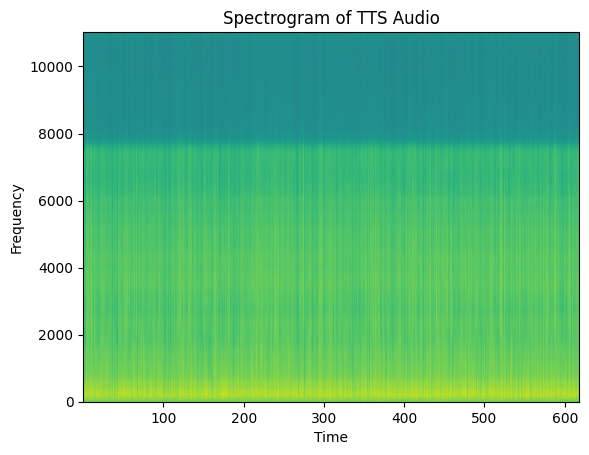

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import wave

# ===== LOAD WAV =====
with wave.open("piper_output.wav", "rb") as f:
    sample_rate = f.getframerate()
    n_frames = f.getnframes()
    audio = np.frombuffer(f.readframes(n_frames), dtype=np.int16)

# ===== NORMALIZE =====
audio = audio.astype(np.float32) / 32768.0

# ===== PLOT SPECTROGRAM =====
plt.figure()
plt.specgram(audio, Fs=sample_rate)
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title("Spectrogram of TTS Audio")

plt.show()

In [34]:
# import librosa
# import numpy as np
# from fastdtw import fastdtw
# from scipy.spatial.distance import euclidean

# def compute_mdd_score(ref_audio, user_audio, sr=22050):
#     # 1. Trích xuất MFCC
#     ref_mfcc = librosa.feature.mfcc(y=ref_audio.astype(float), sr=sr)
#     user_mfcc = librosa.feature.mfcc(y=user_audio.astype(float), sr=sr)
    
#     # 2. Chạy DTW để tính khoảng cách (distance càng nhỏ phát âm càng giống)
#     distance, path = fastdtw(ref_mfcc.T, user_mfcc.T, dist=euclidean)
    
#     return distance

In [47]:
import sounddevice as sd
from scipy.io.wavfile import write

def record_user_voice(filename="user_voice.wav", duration=2, sr=22050):
    print(f"--- Đang ghi âm trong {duration} giây... (Hãy nói: 你好，很高兴认识你) ---")
    # Ghi âm mono (channels=1)
    recording = sd.rec(int(duration * sr), samplerate=sr, channels=1, dtype='int16')
    sd.wait()
    write(filename, sr, recording)
    print(f"✅ Đã lưu file ghi âm: {filename}")

record_user_voice()

--- Đang ghi âm trong 2 giây... (Hãy nói: 你好，很高兴认识你) ---
✅ Đã lưu file ghi âm: user_voice.wav


In [50]:
import librosa
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean

def calculate_mdd_score(ref_file, user_file):
    # 1. Load audio và đưa về cùng sample rate
    y_ref, sr_ref = librosa.load(ref_file, sr=22050)
    y_user, sr_user = librosa.load(user_file, sr=22050)

    # 2. Trích xuất MFCC (Đặc trưng âm học)
    mfcc_ref = librosa.feature.mfcc(y=y_ref, sr=sr_ref)
    mfcc_user = librosa.feature.mfcc(y=y_user, sr=sr_user)

    # 3. Chạy DTW để tính khoảng cách giữa 2 ma trận MFCC
    # .T để chuyển vị vì fastdtw nhận (n_samples, n_features)
    distance, path = fastdtw(mfcc_ref.T, mfcc_user.T, dist=euclidean)

    # 4. Chuẩn hóa điểm số theo độ dài đường đi (càng nhỏ càng giống)
    normalized_score = distance / len(path)
    
    print(f"--- Kết quả MDD ---")
    print(f"Distance Score: {normalized_score:.2f} (0 là khớp hoàn toàn)")
    
    if normalized_score < 20:
        print("🎯 Đánh giá: Phát âm rất tốt!")
    elif normalized_score < 40:
        print("👍 Đánh giá: Khá ổn, cần chú ý thanh điệu.")
    else:
        print("⚠️ Đánh giá: Phát âm chưa chuẩn, hãy thử lại.")

# Chạy so sánh giữa file từ Piper và file em vừa ghi âm
calculate_mdd_score("piper_output.wav", "user_voice.wav")

--- Kết quả MDD ---
Distance Score: 244.89 (0 là khớp hoàn toàn)
⚠️ Đánh giá: Phát âm chưa chuẩn, hãy thử lại.


In [17]:
import os, wave, numpy as np
import librosa
from fastdtw import fastdtw
from scipy.spatial.distance import cosine # Đổi sang Cosine
from piper.voice import PiperVoice
from IPython.display import Audio, display

# --- CẤU HÌNH ---
PIPER_BASE = os.path.abspath("../models/piper/")
SPEAKER_CONFIG = {
    "chaowen": "chaowen/zh_CN-chaowen-medium.onnx",
    "huayan": "huayan/zh_CN-huayan-medium.onnx",
    "xiao_ya": "xiao_ya/zh_CN-xiao_ya-medium.onnx"
}

def generate_voice_file(text, speaker_name, output_name):
    model_path = os.path.join(PIPER_BASE, SPEAKER_CONFIG[speaker_name])
    if not os.path.exists(model_path): return False
    
    voice = PiperVoice.load(model_path)
    audio_data = []
    for chunk in voice.synthesize(text):
        if hasattr(chunk, 'audio_int16_array'):
            audio_data.append(chunk.audio_int16_array)
    
    full_audio = np.concatenate(audio_data)
    with wave.open(output_name, "wb") as f:
        f.setnchannels(1)
        f.setsampwidth(2)
        f.setframerate(voice.config.sample_rate)
        f.writeframes(full_audio.tobytes())
    return True

def compare_mdd_v2(file1, file2):
    # 1. Load & Trim
    y1, sr1 = librosa.load(file1, sr=22050)
    y2, sr2 = librosa.load(file2, sr=22050)
    y1, _ = librosa.effects.trim(y1)
    y2, _ = librosa.effects.trim(y2)

    # 2. Trích xuất MFCC
    mfcc1 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)
    mfcc2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=13)

    # --- BƯỚC MỚI: CHUẨN HÓA CMVN ---
    # Giúp loại bỏ sự khác biệt về 'loa' và 'âm sắc riêng'
    mfcc1 = (mfcc1 - np.mean(mfcc1, axis=1, keepdims=True)) / (np.std(mfcc1, axis=1, keepdims=True) + 1e-8)
    mfcc2 = (mfcc2 - np.mean(mfcc2, axis=1, keepdims=True)) / (np.std(mfcc2, axis=1, keepdims=True) + 1e-8)

    # 3. Tính DTW với Cosine Distance
    # Cosine trả về giá trị từ 0 đến 2 (càng gần 0 càng giống)
    distance, path = fastdtw(mfcc1.T, mfcc2.T, dist=cosine)
    
    # 4. Chuẩn hóa điểm số theo độ dài path
    # Thường kết quả sẽ nằm trong khoảng 0.0 -> 1.0
    normalized_score = distance / len(path)
    
    return normalized_score

# --- THỰC THI ---
input_text = "所以你看， 颜色这么简单的东西， 在不同的文化里， 它的意思也是不一样的。"
speaker_a = "huayan"
speaker_b = "chaowen" # Thử đổi sang "chaowen" (Nam) để thấy sự khác biệt

file_a = "voice_a.wav"
file_b = "voice_b.wav"

if generate_voice_file(input_text, speaker_a, file_a) and generate_voice_file(input_text, speaker_b, file_b):
    score = compare_mdd_v2(file_a, file_b)
    
    print("\n" + "="*40)
    print(f"KẾT QUẢ MDD (COSINE + CMVN)")
    print(f"Giọng A: {speaker_a} vs Giọng B: {speaker_b}")
    print(f"Score: {score:.4f} (Càng gần 0 càng chuẩn)")
    print("="*40)
    
    # Ngưỡng (Threshold) mới dựa trên Cosine Distance
    if score < 0.15:
        print("🎯 ĐÁNH GIÁ: Phát âm cực chuẩn (Khớp âm vị).")
    elif score < 0.25:
        print("👍 ĐÁNH GIÁ: Khá chuẩn, có thể chấp nhận được.")
    else:
        print("⚠️ ĐÁNH GIÁ: Sai lệch nhiều, hãy kiểm tra lại.")


KẾT QUẢ MDD (COSINE + CMVN)
Giọng A: huayan vs Giọng B: chaowen
Score: 0.6109 (Càng gần 0 càng chuẩn)
⚠️ ĐÁNH GIÁ: Sai lệch nhiều, hãy kiểm tra lại.


In [6]:
import os
import wave
import numpy as np
from piper.voice import PiperVoice
from IPython.display import Audio, display

# --- CONFIGURATION ---
PIPER_BASE = os.path.abspath("../models/piper/")
MALE_SPEAKER = "chaowen"   # Male
FEMALE_SPEAKER = "huayan"  # Female

SPEAKER_CONFIG = {
    "chaowen": "chaowen/zh_CN-chaowen-medium.onnx",
    "huayan": "huayan/zh_CN-huayan-medium.onnx",
    "xiao_ya": "xiao_ya/zh_CN-xiao_ya-medium.onnx"
}

# --- MOCK DATA ---
mock_data = {
    "vietnamese_word": "Quả táo",
    "chinese_word": "苹果",
    "example_vn": "Hôm nay tôi ăn một quả táo.",
    "example_zh": "今天我吃了一个苹果。"
}

def get_audio_array(text, speaker_name):
    model_path = os.path.join(PIPER_BASE, SPEAKER_CONFIG[speaker_name])
    if not os.path.exists(model_path):
        print(f"Model not found: {model_path}")
        return None, 22050
    
    voice = PiperVoice.load(model_path)
    audio_chunks = []
    for chunk in voice.synthesize(text):
        if hasattr(chunk, 'audio_int16_array'):
            audio_chunks.append(chunk.audio_int16_array)
    
    if not audio_chunks:
        return None, voice.config.sample_rate
    
    return np.concatenate(audio_chunks), voice.config.sample_rate

def generate_learning_session(data):
    print(f"--- BẮT ĐẦU PHÁT ÂM ---")
    
    # 1. Vietnamese word (Text only for now, can be TTS if you have a VN model)
    print(f"Tiếng Việt: {data['vietnamese_word']}")
    
    # 2. Chinese word - Male
    print(f"Tiếng Trung (Nam): {data['chinese_word']}")
    audio_m, sr = get_audio_array(data['chinese_word'], MALE_SPEAKER)
    if audio_m is not None: display(Audio(audio_m, rate=sr, autoplay=False))
    
    # 3. Chinese word - Female
    print(f"Tiếng Trung (Nữ): {data['chinese_word']}")
    audio_f, sr = get_audio_array(data['chinese_word'], FEMALE_SPEAKER)
    if audio_f is not None: display(Audio(audio_f, rate=sr, autoplay=False))
    
    # 4. Example in Vietnamese
    print(f"Ví dụ (Việt): {data['example_vn']}")
    
    # 5. Example in Chinese - Male
    print(f"Ví dụ (Trung - Nam): {data['example_zh']}")
    audio_ex_m, sr = get_audio_array(data['example_zh'], MALE_SPEAKER)
    if audio_ex_m is not None: display(Audio(audio_ex_m, rate=sr, autoplay=False))
    
    # 6. Example in Chinese - Female
    print(f"Ví dụ (Trung - Nữ): {data['example_zh']}")
    audio_ex_f, sr = get_audio_array(data['example_zh'], FEMALE_SPEAKER)
    if audio_ex_f is not None: display(Audio(audio_ex_f, rate=sr, autoplay=False))

# Run test
generate_learning_session(mock_data)

--- BẮT ĐẦU PHÁT ÂM ---
Tiếng Việt: Quả táo
Tiếng Trung (Nam): 苹果


/opt/anaconda3/envs/learning_chinese_as_a_journey/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tiếng Trung (Nữ): 苹果


Ví dụ (Việt): Hôm nay tôi ăn một quả táo.
Ví dụ (Trung - Nam): 今天我吃了一个苹果。


Ví dụ (Trung - Nữ): 今天我吃了一个苹果。


In [ ]:
# import os
# import wave
# import numpy as np
# import librosa
# from piper.voice import PiperVoice
# from IPython.display import Audio, display

# # --- CONFIGURATION ---
# PIPER_BASE = os.path.abspath("../models/piper/")
# MALE_SPEAKER = "chaowen"   
# FEMALE_SPEAKER = "huayan"  
# OUTPUT_COMBINED_WAV = "learning_session_combined.wav"
# AUDIO_SPEED = 0.85  # Constant speed (0.75x)

# SPEAKER_CONFIG = {
#     "chaowen": "chaowen/zh_CN-chaowen-medium.onnx",
#     "huayan": "huayan/zh_CN-huayan-medium.onnx",
# }

# # --- MOCK DATA ---
# mock_data = {
#     "vietnamese_word": "Quả táo",
#     "chinese_word": "苹果",
#     "example_vn": "Hôm nay tôi ăn một quả táo.",
#     "example_zh": "今天我吃了一个苹果。"
# }

# def get_audio_array(text, speaker_name):
#     model_path = os.path.join(PIPER_BASE, SPEAKER_CONFIG[speaker_name])
#     if not os.path.exists(model_path):
#         return None, 22050
    
#     voice = PiperVoice.load(model_path)
#     audio_chunks = [chunk.audio_int16_array for chunk in voice.synthesize(text) if hasattr(chunk, 'audio_int16_array')]
    
#     if not audio_chunks:
#         return None, voice.config.sample_rate
    
#     audio_data = np.concatenate(audio_chunks)
    
#     # --- ÁP DỤNG LIBROSA ĐỂ THAY ĐỔI TỐC ĐỘ (TIME STRETCH) ---
#     # Chuyển đổi sang float32 để librosa xử lý
#     audio_float = audio_data.astype(np.float32) / 32768.0
    
#     # Time stretch (tốc độ < 1.0 sẽ làm chậm lại)
#     # n_fft mặc định là 2048, có thể điều chỉnh để cải thiện chất lượng ở tốc độ thấp
#     stretched_audio = librosa.effects.time_stretch(audio_float, rate=AUDIO_SPEED)
    
#     # Chuyển đổi ngược lại sang int16
#     final_audio = (stretched_audio * 32767.0).astype(np.int16)
    
#     return final_audio, voice.config.sample_rate

# def create_silence(duration_sec, sample_rate):
#     """Tạo mảng zero cho khoảng lặng"""
#     return np.zeros(int(duration_sec * sample_rate), dtype=np.int16)

# def generate_combined_session(data):
#     # Sử dụng sample rate chuẩn từ model (thường là 22050)
#     sample_rate = 22050 
#     pause_short = create_silence(0.5, sample_rate) # 0.5s giữa từ
#     pause_long = create_silence(1.5, sample_rate)  # 1.5s giữa các phần chính

#     segments = []

#     print(f"--- Đang tạo file âm thanh tổng hợp (Tốc độ: {AUDIO_SPEED}x) ---")
    
#     # 2. Chinese Word - Male
#     audio_m, _ = get_audio_array(data['chinese_word'], MALE_SPEAKER)
#     if audio_m is not None:
#         segments.append(audio_m)
#         segments.append(pause_short)

#     # 3. Chinese Word - Female
#     audio_f, _ = get_audio_array(data['chinese_word'], FEMALE_SPEAKER)
#     if audio_f is not None:
#         segments.append(audio_f)
#         segments.append(pause_long)

#     # 4. Example in Chinese - Male
#     audio_ex_m, _ = get_audio_array(data['example_zh'], MALE_SPEAKER)
#     if audio_ex_m is not None:
#         segments.append(audio_ex_m)
#         segments.append(pause_short)

#     # 5. Example in Chinese - Female
#     audio_ex_f, _ = get_audio_array(data['example_zh'], FEMALE_SPEAKER)
#     if audio_ex_f is not None:
#         segments.append(audio_ex_f)

#     # Ghép tất cả các đoạn
#     final_audio = np.concatenate(segments)

#     # Xuất file WAV
#     with wave.open(OUTPUT_COMBINED_WAV, "wb") as f:
#         f.setnchannels(1)
#         f.setsampwidth(2) # 16-bit
#         f.setframerate(sample_rate)
#         f.writeframes(final_audio.tobytes())
    
#     print(f"✅ Hoàn tất! Đã lưu: {OUTPUT_COMBINED_WAV}")
#     display(Audio(OUTPUT_COMBINED_WAV, rate=sample_rate))

# # Chạy thử nghiệm
# generate_combined_session(mock_data)

--- Đang tạo file âm thanh tổng hợp (Tốc độ: 0.85x) ---
✅ Hoàn tất! Đã lưu: learning_session_combined.wav


In [ ]:
# import os
# import wave
# import numpy as np
# import librosa
# from piper.voice import PiperVoice
# from IPython.display import Audio, display

# # --- CONFIGURATION ---
# PIPER_BASE = os.path.abspath("../models/piper/")
# MALE_SPEAKER = "chaowen"   
# FEMALE_SPEAKER = "huayan"  
# OUTPUT_COMBINED_WAV = "learning_session_combined.wav"
# AUDIO_SPEED = 1.0  # Constant speed (0.75x)

# SPEAKER_CONFIG = {
#     "chaowen": "chaowen/zh_CN-chaowen-medium.onnx",
#     "huayan": "huayan/zh_CN-huayan-medium.onnx",
# }

# # --- MOCK DATA ---
# mock_data = {
#     "vietnamese_word": "Quả táo",
#     "chinese_word": "苹果",
#     "example_vn": "Hôm nay tôi ăn một quả táo.",
#     "example_zh": "今天我吃了一个苹果。"
# }

# def get_audio_array(text, speaker_name):
#     model_path = os.path.join(PIPER_BASE, SPEAKER_CONFIG[speaker_name])
#     if not os.path.exists(model_path):
#         return None, 22050
    
#     voice = PiperVoice.load(model_path)
#     audio_chunks = [chunk.audio_int16_array for chunk in voice.synthesize(text) if hasattr(chunk, 'audio_int16_array')]
    
#     if not audio_chunks:
#         return None, voice.config.sample_rate
    
#     audio_data = np.concatenate(audio_chunks)
    
#     # --- ÁP DỤNG LIBROSA ĐỂ THAY ĐỔI TỐC ĐỘ (TIME STRETCH) ---
#     # Chuyển đổi sang float32 để librosa xử lý
#     audio_float = audio_data.astype(np.float32) / 32768.0
    
#     # Time stretch (tốc độ < 1.0 sẽ làm chậm lại)
#     # n_fft mặc định là 2048, có thể điều chỉnh để cải thiện chất lượng ở tốc độ thấp
#     stretched_audio = librosa.effects.time_stretch(audio_float, rate=AUDIO_SPEED)
    
#     # Chuyển đổi ngược lại sang int16
#     final_audio = (stretched_audio * 32767.0).astype(np.int16)
    
#     return final_audio, voice.config.sample_rate

# def create_silence(duration_sec, sample_rate):
#     """Tạo mảng zero cho khoảng lặng"""
#     return np.zeros(int(duration_sec * sample_rate), dtype=np.int16)

# def generate_combined_session(data):
#     # Sử dụng sample rate chuẩn từ model (thường là 22050)
#     sample_rate = 22050 
#     pause_short = create_silence(0.5, sample_rate) # 0.5s giữa từ
#     pause_long = create_silence(1.5, sample_rate)  # 1.5s giữa các phần chính

#     segments = []

#     print(f"--- Đang tạo file âm thanh tổng hợp (Tốc độ: {AUDIO_SPEED}x) ---")
    
#     # 2. Chinese Word - Male
#     audio_m, _ = get_audio_array(data['chinese_word'], MALE_SPEAKER)
#     if audio_m is not None:
#         segments.append(audio_m)
#         segments.append(pause_short)

#     # 3. Chinese Word - Female
#     audio_f, _ = get_audio_array(data['chinese_word'], FEMALE_SPEAKER)
#     if audio_f is not None:
#         segments.append(audio_f)
#         segments.append(pause_long)

#     # 4. Example in Chinese - Male
#     audio_ex_m, _ = get_audio_array(data['example_zh'], MALE_SPEAKER)
#     if audio_ex_m is not None:
#         segments.append(audio_ex_m)
#         segments.append(pause_short)

#     # 5. Example in Chinese - Female
#     audio_ex_f, _ = get_audio_array(data['example_zh'], FEMALE_SPEAKER)
#     if audio_ex_f is not None:
#         segments.append(audio_ex_f)

#     # Ghép tất cả các đoạn
#     final_audio = np.concatenate(segments)

#     # Xuất file WAV
#     with wave.open(OUTPUT_COMBINED_WAV, "wb") as f:
#         f.setnchannels(1)
#         f.setsampwidth(2) # 16-bit
#         f.setframerate(sample_rate)
#         f.writeframes(final_audio.tobytes())
    
#     print(f"✅ Hoàn tất! Đã lưu: {OUTPUT_COMBINED_WAV}")
#     display(Audio(OUTPUT_COMBINED_WAV, rate=sample_rate))

# # Chạy thử nghiệm
# generate_combined_session(mock_data)

--- Đang tạo file âm thanh tổng hợp (Tốc độ: 1.0x) ---
✅ Hoàn tất! Đã lưu: learning_session_combined.wav


In [18]:
import os
import wave
import numpy as np
import librosa
import unicodedata
from piper.voice import PiperVoice
from IPython.display import Audio, display

# --- CONFIGURATION ---
PIPER_BASE = os.path.abspath("../models/piper/")
VN_BASE = os.path.abspath("../models/vie/")

VN_FEMALE = "vivos"  # Model tiếng Việt vivos
MALE_SPEAKER = "chaowen"   
FEMALE_SPEAKER = "huayan"  
OUTPUT_COMBINED_WAV = "learning_session_combined_v3.wav"
AUDIO_SPEED = 1.0  # Tốc độ yêu cầu

# Mapping file paths
SPEAKER_CONFIG = {
    # Vietnamese
    "vivos": os.path.join(VN_BASE, "vi_VN-vivos-x_low.onnx"),
    # Chinese
    "chaowen": os.path.join(PIPER_BASE, "chaowen/zh_CN-chaowen-medium.onnx"),
    "huayan": os.path.join(PIPER_BASE, "huayan/zh_CN-huayan-medium.onnx"),
}

# --- MOCK DATA ---
mock_data = {
    "vietnamese_word": "Quả táo",
    "chinese_word": "苹果",
    "example_vn": "Hôm nay tôi ăn một quả táo.",
    "example_zh": "今天我吃了一个苹果。"
}

def clean_text(text):
    """
    Chuẩn hóa văn bản: Chuyển số thành chữ và chuẩn hóa Unicode NFC
    để tránh lỗi 'Missing phoneme' trong Piper.
    """
    number_map = {
        "0": "không", "1": "một", "2": "hai", "3": "ba", "4": "bốn",
        "5": "năm", "6": "sáu", "7": "bảy", "8": "tám", "9": "chín"
    }
    for num, word in number_map.items():
        text = text.replace(num, word)
    
    # Chuẩn hóa Unicode về dạng NFC (Dạng tổ hợp sẵn)
    text = unicodedata.normalize('NFC', text)
    return text

def get_audio_array(text, speaker_key):
    # Làm sạch văn bản trước khi đưa vào TTS
    text = clean_text(text)
    
    model_path = SPEAKER_CONFIG.get(speaker_key)
    if not model_path or not os.path.exists(model_path):
        print(f"⚠️ Model không tồn tại: {model_path}")
        return None, 22050
    
    try:
        voice = PiperVoice.load(model_path)
        audio_chunks = [chunk.audio_int16_array for chunk in voice.synthesize(text) if hasattr(chunk, 'audio_int16_array')]
        
        if not audio_chunks:
            return None, voice.config.sample_rate
        
        audio_data = np.concatenate(audio_chunks)
        audio_float = audio_data.astype(np.float32) / 32768.0
        
        # Time stretch using librosa
        stretched_audio = librosa.effects.time_stretch(audio_float, rate=AUDIO_SPEED)
        final_audio = (stretched_audio * 32767.0).astype(np.int16)
        
        return final_audio, voice.config.sample_rate
    except Exception as e:
        print(f"❌ Lỗi khi xử lý {speaker_key}: {e}")
        return None, 22050

def create_silence(duration_sec, sample_rate=22050):
    return np.zeros(int(duration_sec * sample_rate), dtype=np.int16)

def generate_combined_session(data):
    # Lấy sample rate chuẩn (Thường là 22050 cho Vivos/Chaowen)
    # Trong môi trường MDD, việc đồng nhất sample rate là cực kỳ quan trọng
    sample_rate = 22050 
    pause_short = create_silence(0.6, sample_rate)
    pause_long = create_silence(1.5, sample_rate)

    segments = []
    
    # Cấu trúc trình tự (Text, Speaker_Key, Pause_After)
    sequence = [
        (data['vietnamese_word'], "vivos", pause_short),       # [VN word]
        (data['chinese_word'], MALE_SPEAKER, pause_short),      # [CN word - Male]
        (data['chinese_word'], MALE_SPEAKER, pause_long),     # [CN word - Female]
        
        (data['example_vn'], "vivos", pause_short),            # [VN Ex]
        (data['example_zh'], MALE_SPEAKER, pause_short),        # [CN Ex - Male]
        (data['example_zh'], FEMALE_SPEAKER, pause_long),       # [CN Ex - Female]
        
        (data['example_vn'], "vivos", pause_short),            # [VN Ex]
        (data['example_zh'], FEMALE_SPEAKER, None)             # [CN Ex - Female]
    ]

    print(f"--- Đang tạo audio chất lượng cao (Tốc độ: {AUDIO_SPEED}x, Normalized Text) ---")
    
    for text, speaker, pause in sequence:
        audio, sr = get_audio_array(text, speaker)
        if audio is not None:
            segments.append(audio)
            if pause is not None:
                segments.append(pause)

    if not segments:
        print("⚠️ Không có dữ liệu âm thanh được tạo ra.")
        return

    final_audio = np.concatenate(segments)

    with wave.open(OUTPUT_COMBINED_WAV, "wb") as f:
        f.setnchannels(1)
        f.setsampwidth(2)
        f.setframerate(sample_rate)
        f.writeframes(final_audio.tobytes())
    
    print(f"✅ Hoàn tất! Đã lưu: {OUTPUT_COMBINED_WAV}")
    display(Audio(OUTPUT_COMBINED_WAV, rate=sample_rate))

# Thực thi
generate_combined_session(mock_data)

--- Đang tạo audio chất lượng cao (Tốc độ: 1.0x, Normalized Text) ---


Missing phoneme from id map: 4
Missing phoneme from id map: ̪
Missing phoneme from id map: ̪
Missing phoneme from id map: 6
Missing phoneme from id map: ̪
Missing phoneme from id map: 4
Missing phoneme from id map: ̪
Missing phoneme from id map: ̪
Missing phoneme from id map: 6
Missing phoneme from id map: ̪
Missing phoneme from id map: 4
Missing phoneme from id map: ̪


✅ Hoàn tất! Đã lưu: learning_session_combined_v3.wav


In [ ]:
import torch
from diffusers import StableDiffusionPipeline, LCMScheduler

device = "mps" if torch.backends.mps.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float32   # 🔥 fix black image
)

pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config)

# 🔥 MUST have this when using LCM scheduler
pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")
pipe.fuse_lora()

pipe = pipe.to(device)

image = pipe(
    "a simple banana, white background, minimal, clean",
    num_inference_steps=4,   # LCM works best with very few steps
    guidance_scale=1.5,
    height=256,
    width=256
).images[0]

image.save("banana.png")

/opt/anaconda3/envs/learning_chinese_as_a_journey/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/learning_chinese_as_a_journey/lib/python3.9/site-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  9.61it/s]
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


In [21]:
# import pandas as pd
# import os
# import json

# # 1. Cấu hình đường dẫn
# input_folder = "../data/hsk_examples_raw/"
# output_folder = "../data/hsk_examples_processed/"

# # Tạo thư mục đầu ra nếu chưa tồn tại
# os.makedirs(output_folder, exist_ok=True)

# def process_meaning(text):
#     """Tách chuỗi thành mảng các nghĩa."""
#     if pd.isna(text):
#         return []
#     meanings = str(text).replace('\r', '\n').split('\n')
#     return [m.strip() for m in meanings if m.strip()]

# def clean_stt(value, default_index):
#     """Ép STT về số nguyên sạch"""
#     if pd.isna(value):
#         return default_index
#     try:
#         return int(float(value))
#     except (ValueError, TypeError):
#         return str(value).strip()

# def clean_pinyin_format(text):
#     """Loại bỏ ký tự đầu và cuối của chuỗi phiên âm CHỈ NẾU chúng là '/' (vd: /jiā/ -> jiā)"""
#     if pd.isna(text):
#         return ""
#     text_str = str(text).strip()
#     if len(text_str) >= 2 and text_str.startswith('/') and text_str.endswith('/'):
#         return text_str[1:-1]
#     return text_str

# def get_column_value(row, possible_names):
#     """Lấy giá trị từ hàng dựa trên danh sách các tên cột có thể có (không phân biệt hoa thường)"""
#     for name in possible_names:
#         # Kiểm tra exact match
#         if name in row.index:
#             return row[name]
#         # Kiểm tra case-insensitive match
#         for col in row.index:
#             if str(col).strip().lower() == name.lower():
#                 return row[col]
#     return None

# # 2. Duyệt tất cả file trong thư mục đầu vào
# for file_name in os.listdir(input_folder):
#     if file_name.endswith(".xlsx") and not file_name.startswith((".", "~$")):
#         file_path = os.path.join(input_folder, file_name)
        
#         try:
#             df = pd.read_excel(file_path, header=1, engine='openpyxl')
            
#             processed_dict = {}
#             current_hanzi = None
            
#             # Định nghĩa mapping cho các cột quan trọng
#             col_map = {
#                 'hanzi': ['Từ tiếng Trung', 'Từ tiếng trung', 'Hán tự'],
#                 'pinyin': ['Phiên âm'],
#                 'vietnamese': ['Nghĩa tiếng Việt', 'Nghĩa tiếng việt', 'Hán Việt'],
#                 'type': ['Loại từ'],
#                 'eg_chinese': ['Đặt câu'],
#                 'eg_pinyin': ['Phiên âm câu'],
#                 'eg_vietnamese': ['Nghĩa của câu']
#             }
            
#             for index, row in df.iterrows():
#                 raw_hanzi = get_column_value(row, col_map['hanzi'])
#                 raw_hanzi = str(raw_hanzi).strip() if pd.notna(raw_hanzi) else ""
                
#                 if raw_hanzi:
#                     current_hanzi = raw_hanzi
#                     processed_dict[current_hanzi] = {
#                         "id": clean_stt(row.get('STT', index + 1), index + 1),
#                         "pinyin": clean_pinyin_format(get_column_value(row, col_map['pinyin'])),
#                         "vietnamese": process_meaning(get_column_value(row, col_map['vietnamese'])),
#                         "english": [], 
#                         "type": str(get_column_value(row, col_map['type'])).strip() if pd.notna(get_column_value(row, col_map['type'])) else "",
#                         "eg_chinese": str(get_column_value(row, col_map['eg_chinese'])).strip() if pd.notna(get_column_value(row, col_map['eg_chinese'])) else "",
#                         "eg_pinyin": clean_pinyin_format(get_column_value(row, col_map['eg_pinyin'])),
#                         "eg_vietnamese": str(get_column_value(row, col_map['eg_vietnamese'])).strip() if pd.notna(get_column_value(row, col_map['eg_vietnamese'])) else ""
#                     }
#                 elif current_hanzi is not None:
#                     new_vi = process_meaning(get_column_value(row, col_map['vietnamese']))
#                     if new_vi:
#                         processed_dict[current_hanzi]["vietnamese"].extend(new_vi)
            
#             for hanzi in processed_dict:
#                 processed_dict[hanzi]["vietnamese"] = list(dict.fromkeys(processed_dict[hanzi]["vietnamese"]))

#             output_file_name = file_name.replace(".xlsx", ".json")
#             output_path = os.path.join(output_folder, output_file_name)
            
#             with open(output_path, 'w', encoding='utf-8') as f:
#                 json.dump(processed_dict, f, ensure_ascii=False, indent=4)
                
#             print(f"✅ Đã xử lý thành công: {file_name}")
            
#         except Exception as e:
#             print(f"❌ Lỗi khi xử lý file {file_name}: {e}")

# print("\n--- HOÀN TẤT ---")

In [22]:
# import os
# import json

# # --- ĐƯỜNG DẪN ---
# SOURCE_DIR = "../data/hsk_examples_processed/"
# # Thư mục đích nhận cập nhật
# TARGET_DIRS = ["../data/hsk_vocab_up2date/", "../data/hsk_vocab_processed/"]

# def update_vocab_data():
#     # Lấy danh sách file JSON trong thư mục nguồn (hsk_examples_processed)
#     source_files = [f for f in os.listdir(SOURCE_DIR) if f.endswith('.json')]
    
#     if not source_files:
#         print("Không tìm thấy file JSON nào trong thư mục nguồn.")
#         return

#     for target_dir in TARGET_DIRS:
#         print(f"\n--- Đang cập nhật thư mục: {target_dir} ---")
#         for file_name in source_files:
#             source_path = os.path.join(SOURCE_DIR, file_name)
#             target_path = os.path.join(target_dir, file_name)

#             # Kiểm tra xem file tương ứng có tồn tại ở thư mục đích không
#             if not os.path.exists(target_path):
#                 print(f"⚠️ Bỏ qua {file_name}: Không tìm thấy file trong {target_dir}")
#                 continue

#             try:
#                 # Đọc dữ liệu từ source (chứa các trường mới)
#                 with open(source_path, 'r', encoding='utf-8') as f:
#                     source_data = json.load(f)

#                 # Đọc dữ liệu từ target (cần cập nhật)
#                 with open(target_path, 'r', encoding='utf-8') as f:
#                     target_data = json.load(f)

#                 updated_count = 0
#                 # Cập nhật các trường: "type", "eg_chinese", "eg_pinyin", "eg_vietnamese"
#                 fields_to_add = ["type", "eg_chinese", "eg_pinyin", "eg_vietnamese"]

#                 for word, source_info in source_data.items():
#                     if word in target_data:
#                         for field in fields_to_add:
#                             target_data[word][field] = source_info.get(field, "")
#                         updated_count += 1
                
#                 # Lưu lại file đã cập nhật
#                 with open(target_path, 'w', encoding='utf-8') as f:
#                     json.dump(target_data, f, ensure_ascii=False, indent=4)
                
#                 print(f"✅ Đã cập nhật {updated_count} từ trong: {file_name}")

#             except Exception as e:
#                 print(f"❌ Lỗi khi xử lý file {file_name} tại {target_dir}: {e}")

# update_vocab_data()
# print("\n--- Hoàn tất cập nhật dữ liệu từ ví dụ vào cả 2 thư mục vocab ---")

In [ ]:
# import os
# import json
# from openai import OpenAI
# from tqdm.notebook import tqdm

# # =======================
# # Setup OpenAI client
# # =======================
# api_key = ""  # ⚠️ không hardcode key thật
# client = OpenAI(api_key=api_key)


# # =======================
# # Generate example sentence
# # =======================
# def generate_sentence_for_meaning(word, pinyin, meaning):
#     """
#     Generate example sentence using OpenAI.
#     Return dict or None.
#     """
#     prompt = (
#         f"You are a Chinese language teacher. Generate a short, natural example sentence in Chinese "
#         f"for the word '{word}' (Pinyin: {pinyin}) corresponding to its Vietnamese meaning '{meaning}'.\n"
#         f"Output MUST be ONLY a JSON object with keys: eg_chinese, eg_pinyin, eg_vietnamese.\n"
#         f"Do not include markdown. Only raw JSON."
#     )

#     try:
#         response = client.chat.completions.create(
#             model="gpt-4o-mini",
#             messages=[
#                 {"role": "system", "content": "You output only valid JSON."},
#                 {"role": "user", "content": prompt}
#             ],
#             response_format={"type": "json_object"}
#         )

#         data = json.loads(response.choices[0].message.content)

#         return {
#             "eg_chinese": data.get("eg_chinese", ""),
#             "eg_pinyin": data.get("eg_pinyin", ""),
#             "eg_vietnamese": data.get("eg_vietnamese", "")
#         }

#     except Exception as e:
#         print(f"[ERROR] {word} ({meaning}): {e}")
#         return None


# # =======================
# # Main processing
# # =======================
# def process_all_vocab_files():
#     base_dir = "../data/hsk_vocab_processed"
#     output_dir = "../data/hsk_vocab_up2date"

#     os.makedirs(output_dir, exist_ok=True)

#     files = sorted([f for f in os.listdir(base_dir) if f.endswith(".json")])

#     for file_name in files:
#         print(f"\n>>> Processing {file_name}...")

#         input_path = os.path.join(base_dir, file_name)
#         output_path = os.path.join(output_dir, file_name)

#         # Load JSON (dict format: {word: {...}})
#         with open(input_path, "r", encoding="utf-8") as f:
#             data = json.load(f)

#         # Iterate correctly over dict
#         for hanzi, entry in tqdm(data.items(), desc=file_name):

#             word_pinyin = entry.get("pinyin", "")

#             # Handle both list and string
#             meanings = entry.get("vietnamese", [])
#             if isinstance(meanings, str):
#                 meanings = meanings.split(";")

#             meanings = [m.strip() for m in meanings if m.strip()]

#             examples = []

#             for m in meanings:
#                 example = generate_sentence_for_meaning(hanzi, word_pinyin, m)

#                 if example:
#                     examples.append(example)

#                     # Real-time logging
#                     print(f"\n[WORD] {hanzi} | [MEANING] {m}")
#                     print(f"  ZH: {example['eg_chinese']}")
#                     print(f"  PY: {example['eg_pinyin']}")
#                     print(f"  VI: {example['eg_vietnamese']}")
#                     print("-" * 40)

#             # Save into entry
#             entry["eg"] = examples

#             # Save incrementally (avoid losing progress)
#             with open(output_path, "w", encoding="utf-8") as f:
#                 json.dump(data, f, ensure_ascii=False, indent=4)


# # =======================
# # Run
# # =======================
# process_all_vocab_files()

In [26]:
# import os
# import json
# import time
# from openai import OpenAI
# from tqdm.notebook import tqdm
# from dotenv import load_dotenv

# # =======================
# # LOAD ENV
# # =======================
# load_dotenv("../.env")

# # =======================
# # CONFIG
# # =======================
# BATCH_SIZE = 10
# MAX_RETRY = 3
# SLEEP_TIME = 1

# client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


# # =======================
# # Check if word needs processing
# # =======================
# def needs_generation(entry):
#     eg = entry.get("eg", None)

#     if eg is None:
#         return True
#     if not isinstance(eg, list):
#         return True
#     if len(eg) == 0:
#         return True

#     return False


# # =======================
# # Validate output (RELAXED)
# # =======================
# def validate_batch_output(result, batch_words):
#     for item in batch_words:
#         hanzi = item["hanzi"]

#         if hanzi not in result:
#             return False

#         returned = result[hanzi]

#         if not isinstance(returned, list):
#             return False

#         if len(returned) == 0:
#             return False

#     return True


# # =======================
# # Generate batch
# # =======================
# def generate_batch_examples(batch_words):
#     prompt = """
# You are a Chinese teacher.

# For each Chinese word, generate natural example sentence(s) based on the Vietnamese meanings.

# Return ONLY valid JSON in this format:
# {
#   "WORD": [
#     {
#       "meaning": "...",
#       "eg_chinese": "...",
#       "eg_pinyin": "...",
#       "eg_vietnamese": "..."
#     }
#   ]
# }

# Rules:
# - You may generate one or more examples depending on the meanings
# - Keep sentences short and natural
# - No explanations, only JSON
# """

#     prompt += "\nDATA:\n"

#     for item in batch_words:
#         prompt += f"- Word: {item['hanzi']} (Pinyin: {item['pinyin']})\n"
#         prompt += f"  Meanings: {', '.join(item['meanings'])}\n"

#     for attempt in range(MAX_RETRY):
#         try:
#             response = client.chat.completions.create(
#                 model="gpt-4o-mini",
#                 messages=[
#                     {"role": "system", "content": "You output only JSON."},
#                     {"role": "user", "content": prompt}
#                 ],
#                 response_format={"type": "json_object"}
#             )

#             result = json.loads(response.choices[0].message.content)

#             if validate_batch_output(result, batch_words):
#                 return result
#             else:
#                 print(f"[WARN] Invalid format, retry {attempt+1}")

#         except Exception as e:
#             print(f"[ERROR] Batch failed (attempt {attempt+1}): {e}")

#         time.sleep(SLEEP_TIME)

#     return None


# # =======================
# # Normalize meanings
# # =======================
# def normalize_meanings(meanings_raw):
#     import re

#     if isinstance(meanings_raw, str):
#         meanings_raw = re.split(r"[;,]", meanings_raw)

#     meanings = []
#     for m in meanings_raw:
#         parts = re.split(r"[;,]", m)
#         for p in parts:
#             p = p.strip()
#             if p:
#                 meanings.append(p)

#     return meanings


# # =======================
# # Sync eg back to input
# # =======================
# def sync_eg_to_input(input_path, output_path):
#     with open(input_path, "r", encoding="utf-8") as f:
#         input_data = json.load(f)

#     with open(output_path, "r", encoding="utf-8") as f:
#         output_data = json.load(f)

#     updated_count = 0

#     for hanzi in input_data:
#         if hanzi in output_data and "eg" in output_data[hanzi]:
#             input_data[hanzi]["eg"] = output_data[hanzi]["eg"]
#             updated_count += 1

#     with open(input_path, "w", encoding="utf-8") as f:
#         json.dump(input_data, f, ensure_ascii=False, indent=4)

#     print(f"✅ Synced {updated_count} entries back to input file")


# # =======================
# # Main
# # =======================
# def process_all_vocab_files():
#     base_dir = "../data/hsk_vocab_processed"
#     output_dir = "../data/hsk_vocab_up2date"

#     os.makedirs(output_dir, exist_ok=True)

#     files = sorted([f for f in os.listdir(base_dir) if f.endswith(".json")])

#     for file_name in files:
#         print(f"\n>>> Processing {file_name}...")

#         input_path = os.path.join(base_dir, file_name)
#         output_path = os.path.join(output_dir, file_name)

#         # Load input
#         with open(input_path, "r", encoding="utf-8") as f:
#             data = json.load(f)

#         # Resume nếu có output
#         if os.path.exists(output_path):
#             with open(output_path, "r", encoding="utf-8") as f:
#                 data = json.load(f)

#         items = []

#         for hanzi, entry in data.items():
#             meanings = normalize_meanings(entry.get("vietnamese", []))

#             items.append({
#                 "hanzi": hanzi,
#                 "pinyin": entry.get("pinyin", ""),
#                 "meanings": meanings
#             })

#         # Batch processing
#         for i in tqdm(range(0, len(items), BATCH_SIZE), desc=file_name):
#             batch = items[i:i+BATCH_SIZE]

#             batch_to_process = [
#                 item for item in batch
#                 if needs_generation(data[item["hanzi"]])
#             ]

#             if len(batch_to_process) == 0:
#                 continue

#             result = generate_batch_examples(batch_to_process)

#             if not result:
#                 print(f"[SKIP] Batch {i}")
#                 continue

#             for word_obj in batch_to_process:
#                 hanzi = word_obj["hanzi"]

#                 if hanzi in result:
#                     data[hanzi]["eg"] = result[hanzi]

#                     for ex in result[hanzi]:
#                         print(f"\n[WORD] {hanzi} | {ex.get('meaning', '')}")
#                         print(f"  ZH: {ex.get('eg_chinese', '')}")
#                         print(f"  PY: {ex.get('eg_pinyin', '')}")
#                         print(f"  VI: {ex.get('eg_vietnamese', '')}")
#                         print("-" * 40)

#             with open(output_path, "w", encoding="utf-8") as f:
#                 json.dump(data, f, ensure_ascii=False, indent=4)

#             time.sleep(SLEEP_TIME)

#         # 🔥 SYNC BACK TO INPUT
#         sync_eg_to_input(input_path, output_path)


# # =======================
# # RUN
# # =======================
# process_all_vocab_files()


>>> Processing hsk_1.json...


hsk_1.json:   0%|          | 0/52 [00:00<?, ?it/s]

✅ Synced 518 entries back to input file

>>> Processing hsk_2.json...


hsk_2.json:   0%|          | 0/77 [00:00<?, ?it/s]

✅ Synced 764 entries back to input file

>>> Processing hsk_3.json...


...

✅ Synced 1991 entries back to input file

>>> Processing hsk_789_part_2.json...


hsk_789_part_2.json:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Synced 1995 entries back to input file

>>> Processing hsk_789_part_3.json...


hsk_789_part_3.json:   0%|          | 0/164 [00:00<?, ?it/s]

[WARN] Invalid format, retry 1
[WARN] Invalid format, retry 2
[WARN] Invalid format, retry 3
[SKIP] Batch 860
✅ Synced 1629 entries back to input file


In [27]:
"""import os
import json
import time
from openai import OpenAI
from tqdm.notebook import tqdm
from dotenv import load_dotenv

# =======================
# LOAD ENV
# =======================
load_dotenv("../.env")

# =======================
# CONFIG
# =======================
BATCH_SIZE = 10
MAX_RETRY = 3
SLEEP_TIME = 1

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# =======================
# Check if word needs processing
# =======================
def needs_generation(entry):
    eg = entry.get("eg", None)

    if eg is None:
        return True
    if not isinstance(eg, list):
        return True
    if len(eg) == 0:
        return True

    return False


# =======================
# Validate output (DEBUG)
# =======================
def validate_batch_output(result, batch_words):
    for item in batch_words:
        hanzi = item["hanzi"]

        if hanzi not in result:
            print(f"[INVALID] Missing word: {hanzi}")
            return False

        returned = result[hanzi]

        if not isinstance(returned, list):
            print(f"[INVALID] Not list: {hanzi}")
            return False

        if len(returned) == 0:
            print(f"[INVALID] Empty list: {hanzi}")
            return False

    return True


# =======================
# Save debug batch
# =======================
def save_debug_batch(batch_words, raw_output, batch_id, file_name):
    debug_dir = "../debug_batches"
    os.makedirs(debug_dir, exist_ok=True)

    path = os.path.join(
        debug_dir,
        f"{file_name}_batch_{batch_id}.json"
    )

    debug_data = {
        "batch_id": batch_id,
        "file": file_name,
        "input": batch_words,
        "raw_output": raw_output
    }

    with open(path, "w", encoding="utf-8") as f:
        json.dump(debug_data, f, ensure_ascii=False, indent=4)

    print(f"[DEBUG SAVED] -> {path}")


# =======================
# Generate batch
# =======================
def generate_batch_examples(batch_words, batch_id=None, file_name=None):
    prompt = """
You are a Chinese teacher.

For each Chinese word, generate natural example sentence(s) based on the Vietnamese meanings.

Return ONLY valid JSON in this format:
{
  "WORD": [
    {
      "meaning": "...",
      "eg_chinese": "...",
      "eg_pinyin": "...",
      "eg_vietnamese": "..."
    }
  ]
}

Rules:
- You may generate one or more examples depending on the meanings
- Keep sentences short and natural
- No explanations, only JSON
"""

    prompt += "\nDATA:\n"

    for item in batch_words:
        prompt += f"- Word: {item['hanzi']} (Pinyin: {item['pinyin']})\n"
        prompt += f"  Meanings: {', '.join(item['meanings'])}\n"

    for attempt in range(MAX_RETRY):
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": "You output only JSON."},
                    {"role": "user", "content": prompt}
                ],
                response_format={"type": "json_object"}
            )

            raw_text = response.choices[0].message.content

            # 🔥 Try parse JSON
            try:
                result = json.loads(raw_text)
            except Exception as e:
                print(f"\n[JSON ERROR] Cannot parse response (attempt {attempt+1})")
                print(f"[Batch {batch_id} | {file_name}]")
                print("Raw response preview:")
                print(raw_text[:1000])

                save_debug_batch(batch_words, raw_text, batch_id, file_name)
                continue

            # 🔥 Validate structure
            if validate_batch_output(result, batch_words):
                return result
            else:
                print(f"\n[WARN] Invalid format, retry {attempt+1}")
                print(f"[Batch {batch_id} | {file_name}]")

                save_debug_batch(batch_words, raw_text, batch_id, file_name)

        except Exception as e:
            print(f"\n[ERROR] Batch failed (attempt {attempt+1}): {e}")
            print(f"[Batch {batch_id} | {file_name}]")

            save_debug_batch(batch_words, None, batch_id, file_name)

        time.sleep(SLEEP_TIME)

    return None


# =======================
# Normalize meanings
# =======================
def normalize_meanings(meanings_raw):
    import re

    if isinstance(meanings_raw, str):
        meanings_raw = re.split(r"[;,]", meanings_raw)

    meanings = []
    for m in meanings_raw:
        parts = re.split(r"[;,]", m)
        for p in parts:
            p = p.strip()
            if p:
                meanings.append(p)

    return meanings


# =======================
# Sync eg back to input
# =======================
def sync_eg_to_input(input_path, output_path):
    with open(input_path, "r", encoding="utf-8") as f:
        input_data = json.load(f)

    with open(output_path, "r", encoding="utf-8") as f:
        output_data = json.load(f)

    updated_count = 0

    for hanzi in input_data:
        if hanzi in output_data and "eg" in output_data[hanzi]:
            input_data[hanzi]["eg"] = output_data[hanzi]["eg"]
            updated_count += 1

    with open(input_path, "w", encoding="utf-8") as f:
        json.dump(input_data, f, ensure_ascii=False, indent=4)

    print(f"✅ Synced {updated_count} entries back to input file")


# =======================
# Main
# =======================
def process_all_vocab_files():
    base_dir = "../data/hsk_vocab_processed"
    output_dir = "../data/hsk_vocab_up2date"

    os.makedirs(output_dir, exist_ok=True)

    files = sorted([f for f in os.listdir(base_dir) if f.endswith(".json")])

    for file_name in files:
        print(f"\n>>> Processing {file_name}...")

        input_path = os.path.join(base_dir, file_name)
        output_path = os.path.join(output_dir, file_name)

        # Load input
        with open(input_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Resume nếu có output
        if os.path.exists(output_path):
            with open(output_path, "r", encoding="utf-8") as f:
                data = json.load(f)

        items = []

        for hanzi, entry in data.items():
            meanings = normalize_meanings(entry.get("vietnamese", []))

            items.append({
                "hanzi": hanzi,
                "pinyin": entry.get("pinyin", ""),
                "meanings": meanings
            })

        # =======================
        # Batch processing
        # =======================
        for i in tqdm(range(0, len(items), BATCH_SIZE), desc=file_name):
            batch = items[i:i+BATCH_SIZE]

            batch_to_process = [
                item for item in batch
                if needs_generation(data[item["hanzi"]])
            ]

            if len(batch_to_process) == 0:
                continue

            result = generate_batch_examples(
                batch_to_process,
                batch_id=i,
                file_name=file_name
            )

            if not result:
                print(f"[SKIP] Batch {i}")
                continue

            for word_obj in batch_to_process:
                hanzi = word_obj["hanzi"]

                if hanzi in result:
                    data[hanzi]["eg"] = result[hanzi]

                    for ex in result[hanzi]:
                        print(f"\n[WORD] {hanzi} | {ex.get('meaning', '')}")
                        print(f"  ZH: {ex.get('eg_chinese', '')}")
                        print(f"  PY: {ex.get('eg_pinyin', '')}")
                        print(f"  VI: {ex.get('eg_vietnamese', '')}")
                        print("-" * 40)

            with open(output_path, "w", encoding="utf-8") as f:
                json.dump(data, f, ensure_ascii=False, indent=4)

            time.sleep(SLEEP_TIME)

        # 🔥 Sync back
        sync_eg_to_input(input_path, output_path)


# =======================
# RUN
# =======================
process_all_vocab_files()"""


>>> Processing hsk_1.json...


hsk_1.json:   0%|          | 0/52 [00:00<?, ?it/s]

✅ Synced 518 entries back to input file

>>> Processing hsk_2.json...


hsk_2.json:   0%|          | 0/77 [00:00<?, ?it/s]

✅ Synced 764 entries back to input file

>>> Processing hsk_3.json...


...

✅ Synced 1991 entries back to input file

>>> Processing hsk_789_part_2.json...


hsk_789_part_2.json:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Synced 1995 entries back to input file

>>> Processing hsk_789_part_3.json...


hsk_789_part_3.json:   0%|          | 0/164 [00:00<?, ?it/s]

[INVALID] Missing word: 业(服务业）

[WARN] Invalid format, retry 1
[Batch 860 | hsk_789_part_3.json]
[DEBUG SAVED] -> ../debug_batches/hsk_789_part_3.json_batch_860.json
[INVALID] Missing word: 业(服务业）

[WARN] Invalid format, retry 2
[Batch 860 | hsk_789_part_3.json]
[DEBUG SAVED] -> ../debug_batches/hsk_789_part_3.json_batch_860.json
[INVALID] Missing word: 业(服务业）

[WARN] Invalid format, retry 3
[Batch 860 | hsk_789_part_3.json]
[DEBUG SAVED] -> ../debug_batches/hsk_789_part_3.json_batch_860.json
[SKIP] Batch 860
✅ Synced 1629 entries back to input file


In [30]:
import os
import json

# =======================
# PATH
# =======================
src_dir = "../data/hsk_vocab_processed"
dst_dir = "../data/hsk_vocab_up2date"

files = [f for f in os.listdir(src_dir) if f.endswith(".json")]

total_updated = 0

for file_name in files:
    src_path = os.path.join(src_dir, file_name)
    dst_path = os.path.join(dst_dir, file_name)

    if not os.path.exists(dst_path):
        print(f"[SKIP] {file_name} (no target file)")
        continue

    # Load data
    with open(src_path, "r", encoding="utf-8") as f:
        src_data = json.load(f)

    with open(dst_path, "r", encoding="utf-8") as f:
        dst_data = json.load(f)

    updated_count = 0

    # 🔥 FORCE OVERWRITE
    for hanzi in src_data:
        if hanzi in dst_data:
            # nếu src không có eg → vẫn set None (force đúng nghĩa)
            dst_data[hanzi]["eg"] = src_data[hanzi].get("eg", None)
            updated_count += 1

    # Save back
    with open(dst_path, "w", encoding="utf-8") as f:
        json.dump(dst_data, f, ensure_ascii=False, indent=4)

    total_updated += updated_count
    print(f"[DONE] {file_name}: force updated {updated_count} entries")

print(f"\n🔥 TOTAL FORCE UPDATED: {total_updated}")

[DONE] hsk_6.json: force updated 1226 entries
[DONE] hsk_789_part_1.json: force updated 1991 entries
[DONE] hsk_1.json: force updated 518 entries
[DONE] hsk_789_part_2.json: force updated 1995 entries
[DONE] hsk_2.json: force updated 764 entries
[DONE] hsk_3.json: force updated 973 entries
[DONE] hsk_789_part_3.json: force updated 1639 entries
[DONE] hsk_4.json: force updated 995 entries
[DONE] hsk_5.json: force updated 1506 entries

🔥 TOTAL FORCE UPDATED: 11607


In [29]:
import os
import json

base_dir = "../data/hsk_vocab_processed"

files = [f for f in os.listdir(base_dir) if f.endswith(".json")]

total_missing = 0

for file_name in files:
    path = os.path.join(base_dir, file_name)

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    missing_words = []

    for hanzi, entry in data.items():
        eg = entry.get("eg", None)

        if eg is None or not isinstance(eg, list) or len(eg) == 0:
            missing_words.append(hanzi)

    if missing_words:
        print(f"\n[FILE] {file_name}")
        print(f"Missing eg: {len(missing_words)} words")

        for w in missing_words[:20]:  # tránh spam
            print(f" - {w}")

        if len(missing_words) > 20:
            print(" ...")

    total_missing += len(missing_words)

print(f"\n❌ TOTAL words missing eg: {total_missing}")


❌ TOTAL words missing eg: 0


In [33]:
import json
from collections import OrderedDict

file_path = "../data/hsk_vocab_up2date/hsk_unknown.json"

# Load
with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

new_data = {}

for hanzi, entry in data.items():
    new_entry = OrderedDict()

    # 1. id lên đầu
    if "id" in entry:
        new_entry["id"] = entry["id"]

    # 2. pinyin
    if "pinyin" in entry:
        new_entry["pinyin"] = entry["pinyin"]

    # 3. vietnamese
    if "vietnamese" in entry:
        new_entry["vietnamese"] = entry["vietnamese"]

    # 4. english
    if "english" in entry:
        new_entry["english"] = entry["english"]

    # 🔥 5. thêm num_appear ngay sau english
    new_entry["num_appear"] = 0

    # 6. eg
    if "eg" in entry:
        new_entry["eg"] = entry["eg"]

    # ❌ bỏ hsk_level và freq (không add lại)

    new_data[hanzi] = new_entry

# Save
with open(file_path, "w", encoding="utf-8") as f:
    json.dump(new_data, f, ensure_ascii=False, indent=4)

print("✅ Updated schema: added num_appear, removed hsk_level & freq")

✅ Updated schema: added num_appear, removed hsk_level & freq
